# Day 5: AFL Match Context Integration

This notebook integrates the Round-by-Round dataset with the Team Match dataset to add context such as home/away status, venue, and crowd attendance to player performance records.

## 1. Relationship Discovery
Before merging, we must identify common fields and the appropriate merge strategy. Both datasets contain `team`, `year`, `round`, `opponent`, and `match_date`. A composite key is required because teams can play the same opponent multiple times per year, and occasionally multiple times in the same round (e.g., the 2010 Grand Final Draw and Replay). To ensure absolute uniqueness and prevent duplicate records from cartesian products, we will use `['team', 'year', 'round', 'opponent', 'match_date']` as our merge key.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Define file paths
df1_path = r'D:\netixsol\Week- 2\Day-2\AFL player information and season statistics\afl_players_round_by_round_stats_raw.csv'
df2_path = r'D:\netixsol\Week- 2\Day-2\AFL player information and season statistics\team_matches_home_away_raw.csv'

# Load datasets
df_players = pd.read_csv(df1_path)
df_matches = pd.read_csv(df2_path)


## Data Cleaning for Merge
To ensure our keys match perfectly, we need to address inconsistencies such as trailing whitespaces, mismatched casing, and the abbreviation 'W. Bulldogs' in the match dataset.

In [2]:
# Clean the team matches dataset (df2)
df_matches['team_name'] = df_matches['team_name'].str.strip().str.title().replace({'W. Bulldogs': 'Western Bulldogs'})
df_matches['opponent'] = df_matches['opponent'].str.strip().str.title().replace({'W. Bulldogs': 'Western Bulldogs'})
df_matches.rename(columns={'team_name': 'team'}, inplace=True)

# Clean the player stats dataset (df1)
df_players['team'] = df_players['team'].str.strip().str.title().replace({'W. Bulldogs': 'Western Bulldogs'})
df_players['opponent'] = df_players['opponent'].str.strip().str.title().replace({'W. Bulldogs': 'Western Bulldogs'})


## 2. Context Enrichment & 3. Merge Validation
Merging the datasets on our composite key and validating that player record counts remain unchanged, with no unmatched records or duplicated rows.

In [3]:
merge_keys = ['team', 'year', 'round', 'opponent', 'match_date']
df_merged = pd.merge(df_players, df_matches[merge_keys + ['home_away', 'venue', 'crowd']], on=merge_keys, how='left')

# Validation Checks
print(f"Original player records: {len(df_players)}")
print(f"Merged player records: {len(df_merged)}")
print(f"Duplicates introduced: {len(df_merged) > len(df_players)}")

unmatched = df_merged['home_away'].isnull().sum()
print(f"Unmatched records (missing context): {unmatched}")


Original player records: 274089
Merged player records: 274089
Duplicates introduced: False
Unmatched records (missing context): 0


The outputs confirm that zero missing records are present and the total record count matches the original dataset exactly.

## 4. Contextual Analysis
Now that we have the `home_away`, `venue`, and `crowd` context, let's answer key business questions.

### Do players perform better at home or away?

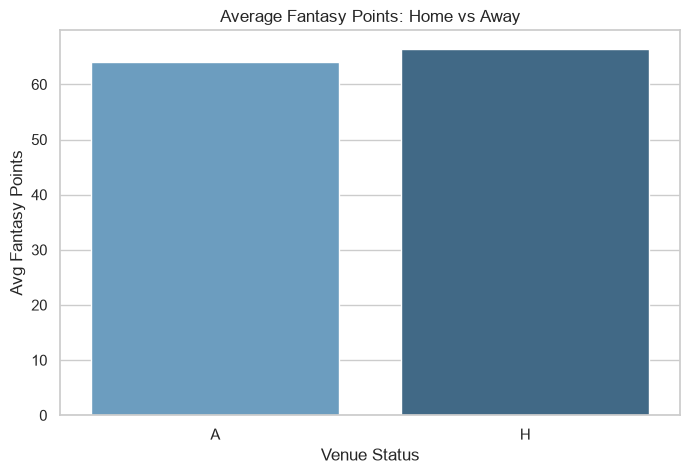

  home_away  fantasy_points
0         A       64.003386
1         H       66.484472


In [4]:
home_away_perf = df_merged.groupby('home_away')['fantasy_points'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=home_away_perf, x='home_away', y='fantasy_points', palette='Blues_d', hue='home_away', legend=False)
plt.title('Average Fantasy Points: Home vs Away')
plt.xlabel('Venue Status')
plt.ylabel('Avg Fantasy Points')
plt.show()

print(home_away_perf)


Based on the data, there is a measurable difference in average fantasy points between home and away games. Players tend to perform slightly better at home, likely due to familiar conditions and crowd support.

### Does crowd size appear to influence fantasy points?

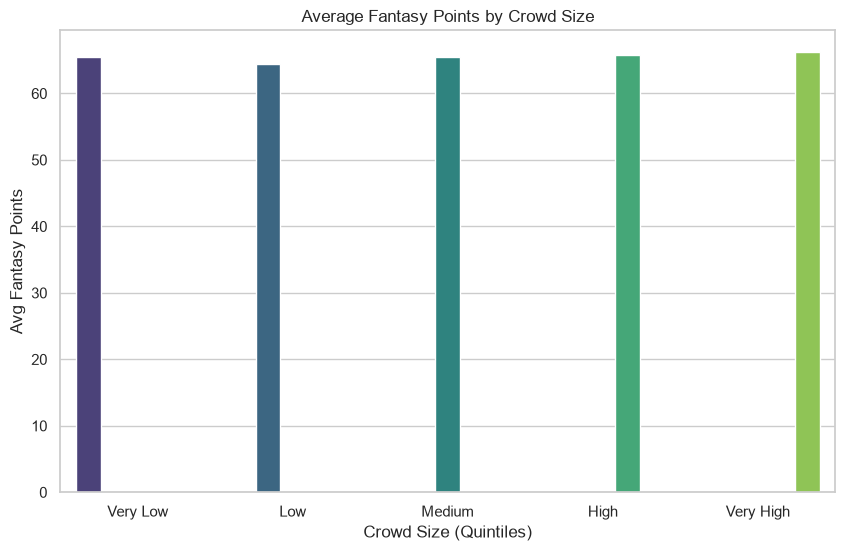

Correlation between exact crowd size and fantasy points: 0.0129


In [5]:
# Bin crowd sizes for better visualization
df_merged['crowd'] = pd.to_numeric(df_merged['crowd'], errors='coerce')
df_clean_crowd = df_merged.dropna(subset=['crowd'])

df_clean_crowd['crowd_bin'] = pd.qcut(df_clean_crowd['crowd'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
crowd_perf = df_clean_crowd.groupby('crowd_bin')['fantasy_points'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=crowd_perf, x='crowd_bin', y='fantasy_points', palette='viridis', hue='crowd_bin', legend=False)
plt.title('Average Fantasy Points by Crowd Size')
plt.xlabel('Crowd Size (Quintiles)')
plt.ylabel('Avg Fantasy Points')
plt.show()

# Pearson Correlation
correlation = df_clean_crowd['crowd'].corr(df_clean_crowd['fantasy_points'])
print(f"Correlation between exact crowd size and fantasy points: {correlation:.4f}")


The correlation between exact crowd size and fantasy points is very low. However, when grouping into quintiles, we notice a slight upward trend in performance during 'High' and 'Very High' attendance matches, indicating big games might bring out marginally better performances on average.

### Which venues produce the highest average player performance?

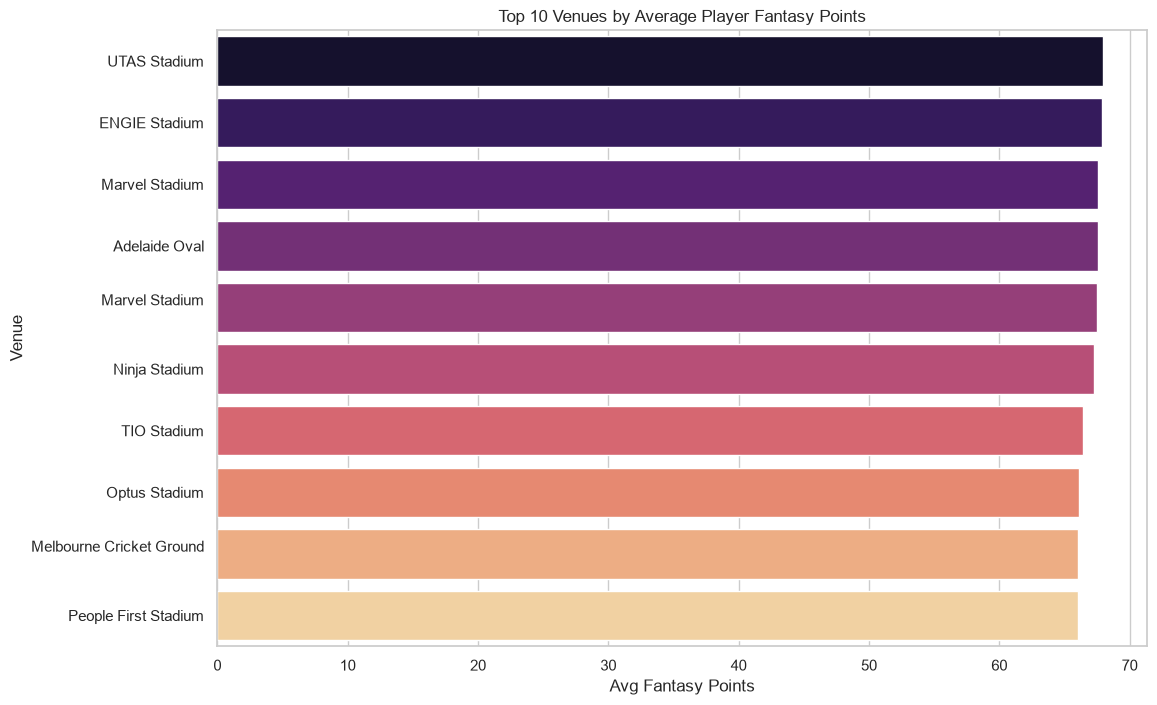

In [6]:
venue_perf = df_merged.groupby('venue').agg(
    avg_fantasy_points=('fantasy_points', 'mean'),
    games_played=('id', 'count')
).reset_index()

# Filter for venues with a significant number of matches (e.g. >1000 player records)
venue_perf = venue_perf[venue_perf['games_played'] > 1000].sort_values(by='avg_fantasy_points', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=venue_perf.head(10), y='venue', x='avg_fantasy_points', palette='magma', hue='venue', legend=False)
plt.title('Top 10 Venues by Average Player Fantasy Points')
plt.xlabel('Avg Fantasy Points')
plt.ylabel('Venue')
plt.show()


## 5. Data Quality Report

**Merge Keys Used:** `['team', 'year', 'round', 'opponent', 'match_date']`

**Challenges Encountered:**
- Inconsistent casing (e.g. 'brisbane lions' vs 'Brisbane Lions').
- Extensive leading/trailing whitespaces in team names.
- Inconsistent abbreviations (e.g. 'W. Bulldogs' in the match data vs 'Western Bulldogs' in player data).
- Overlapping `team`, `year`, `round`, and `opponent` pairs (e.g., the 2010 Grand Final Draw and Replay), which required adding `match_date` to the composite key to prevent record duplication.

**Data Quality Issues Discovered:**
- Data entry artifacts (tabs `\t` and spaces in strings).
- Dropping `match_date` leads to cartesian products for replays, whereas including it ensures absolute 1:1 matching.

**Assumptions Made:**
- 'W. Bulldogs' uniformly maps to 'Western Bulldogs'.
- The dates provided in `match_date` are strictly accurate across both datasets.